In [1]:
import os
import numpy as np
import scipy.io as spio
import struct
import matplotlib.pyplot as plt

In [2]:
N_SEG_IN   = 27904 # number of segments before cut
N_SEG_BIN = 10999 # number of ever active segments after cut

In [3]:
path_dir = r"\\luna\fst\LEC\Users\midauarg\delft_modelling\wq_0.1min_secondfolder\forcing_remapped"
# path_vol = r"\\luna\fst\LEC\Users\midauarg\delft_modelling\wq_0.1min_secondfolder\01scen_baseline\com-WQexport_clean.vol"
path_vol = r"\\luna\fst\LEC\Users\midauarg\delft_modelling\wq_0.1min_secondfolder\com_files\com-WQexport_30min_fullperiod.vol"
path_segnum = r"\\luna\fst\LEC\Users\midauarg\delft_modelling\wq_0.1min_secondfolder\segment number.mat"

In [4]:
paths_bin = [f for f in os.listdir(path_dir) if f.endswith(".bin")]
paths_bin

['waq-wind-noFPV_remapped_column.bin',
 'waq-daily-sw_radiation_flux-03towaq_fpv41_10x10gaps_remapped_column.bin',
 'waq-wind-04towaq_fpv41_donutgap_remapped_column.bin',
 'waq-wind-03towaq_fpv41_10x10gaps_remapped_column.bin',
 'waq-daily-sw_radiation_flux-SRfactor000_remapped_column.bin',
 'waq-daily-sw_radiation_flux-SRfactor010_remapped_column.bin',
 'waq-daily-sw_radiation_flux-02towaq_fpv41_nogaps_remapped_column.bin',
 'waq-wind-totcoverage_SRfactor010_remapped_column.bin',
 'waq-daily-sw_radiation_flux-04towaq_fpv41_donutgap_remapped_column.bin',
 'waq-sw_radiation_flux-noFPV_remapped_column.bin',
 'waq-daily-sw_radiation_flux-totcoverage_SRfactor010_remapped_column.bin',
 'waq-wind-SRfactor010_remapped_column.bin',
 'waq-wind-02towaq_fpv41_nogaps_remapped_column.bin',
 'waq-wind-SRfactor000_remapped_column.bin']

In [5]:
def read_in_chunks(file_path, num_chunks = 1):
    chunk_size = 4 + 4 * N_SEG_BIN
    series = {}
    with open(file_path, "rb") as file:
        for _ in range(num_chunks):
            chunk = file.read(chunk_size) 
            time = struct.unpack('i', chunk[0:4])[0]
            data = np.frombuffer(chunk[4:], dtype=np.float32)
            series[time] = data
    return series

In [6]:
# read segnum with information of grid id
mat = spio.loadmat(path_segnum)
segnum = mat['data'][0,0]['Val']

In [7]:
SCEN_VOL_ORIG = path_vol
rec_size_s    = (N_SEG_IN + 1) * 4
fsize         = os.path.getsize(SCEN_VOL_ORIG)
n_times       = fsize // rec_size_s

ever_active = np.zeros(N_SEG_IN, dtype=bool)
print('Reading baseline original .vol to find ever-active segments...')
with open(SCEN_VOL_ORIG, 'rb') as f:
    for i in range(n_times):
        f.read(4)
        raw = np.frombuffer(f.read(N_SEG_IN * 4), dtype='<f4').copy()
        ever_active |= (raw > 0)
        if (i+1) % 2000 == 0:
            print(f'  {i+1:,}/{n_times:,}...', end='\r')

all_active_idx = np.where(ever_active)[0]
print(f'\nTotal ever-active: {len(all_active_idx)}')
new_to_old = all_active_idx[:N_SEG_BIN]
print(f'Using first {len(new_to_old)} active segments')

Reading baseline original .vol to find ever-active segments...
  14,000/15,032...
Total ever-active: 10999
Using first 10999 active segments


In [8]:
def array_bin_to_grid(x_bin, new_to_old, segnum):
    """Map WAQ segment values to (M, N, K) grid using segnum lookup."""
    # Step 1: place compact-grid values back into full FLOW-segment positions
    x_full = np.full(N_SEG_IN, np.nan, dtype=float)
    x_full[new_to_old] = x_bin

    # Step 2: fancy-index segnum into x_full
    # segnum contains 1-indexed segment IDs with NaN for inactive cells
    out = np.full(segnum.shape, np.nan, dtype=float)
    valid = ~np.isnan(segnum)
    seg_idx = segnum[valid].astype(np.int64) - 1   # 1-indexed → 0-indexed
    out[valid] = x_full[seg_idx]
    return out

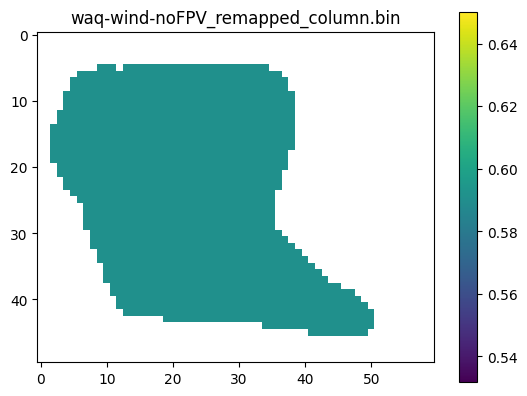

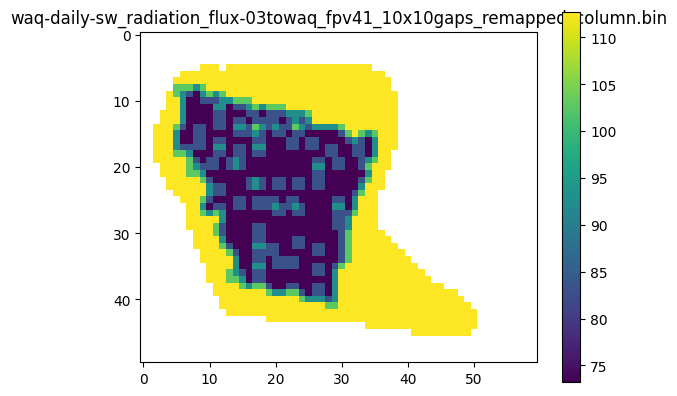

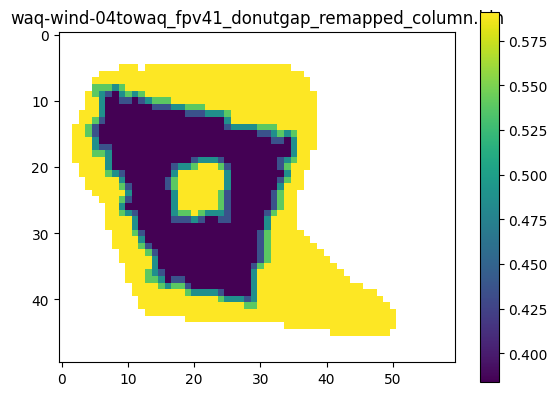

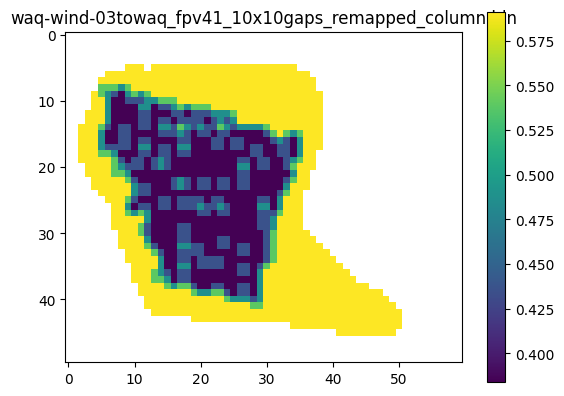

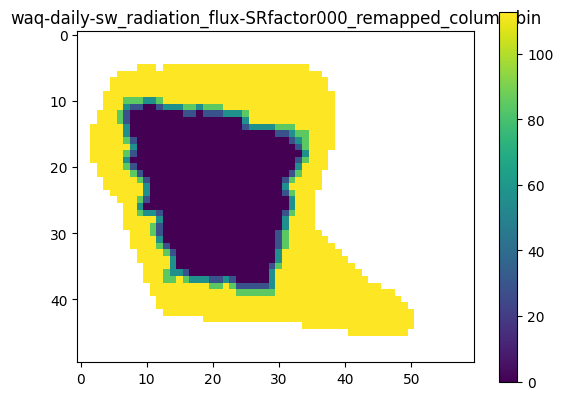

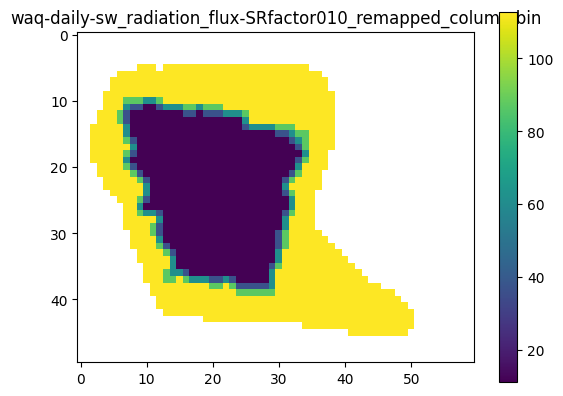

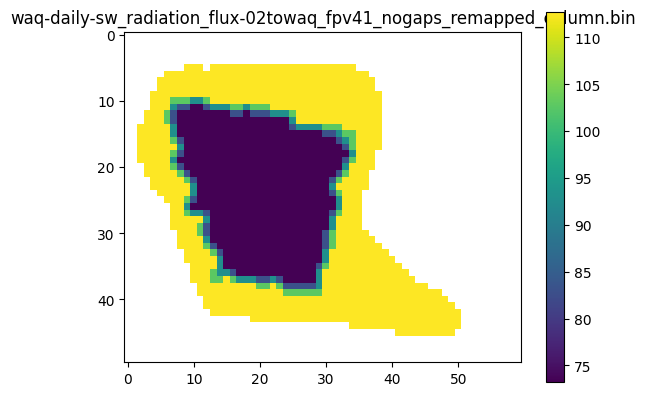

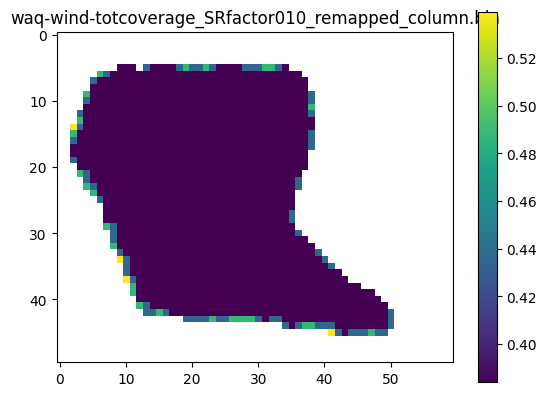

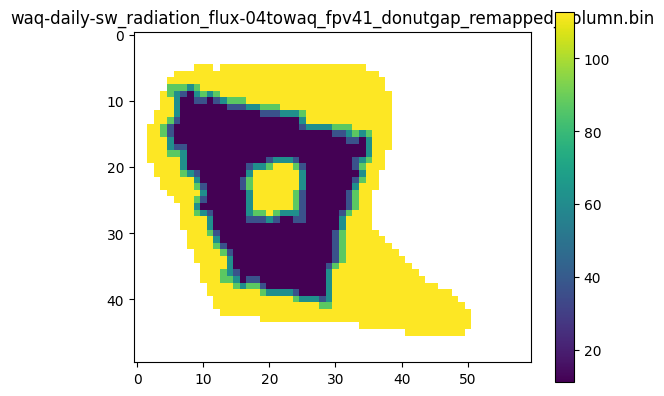

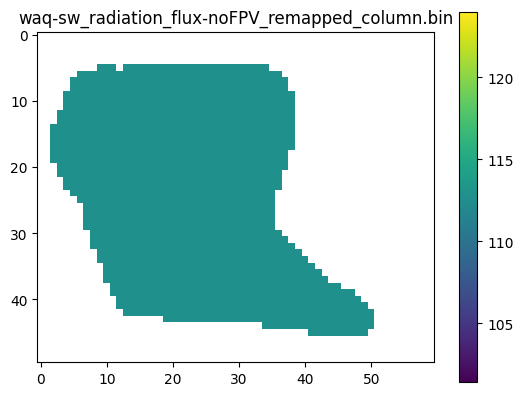

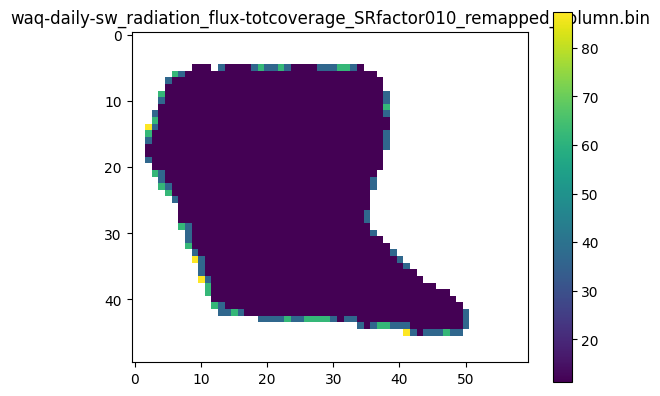

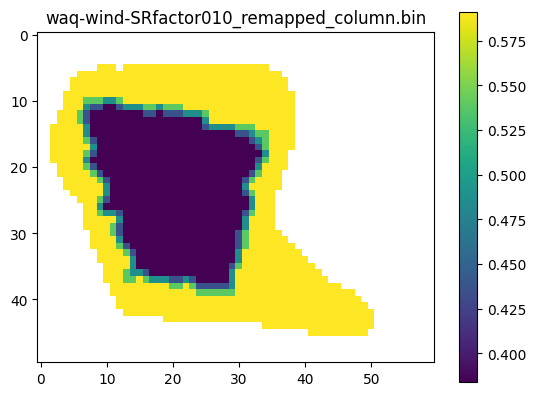

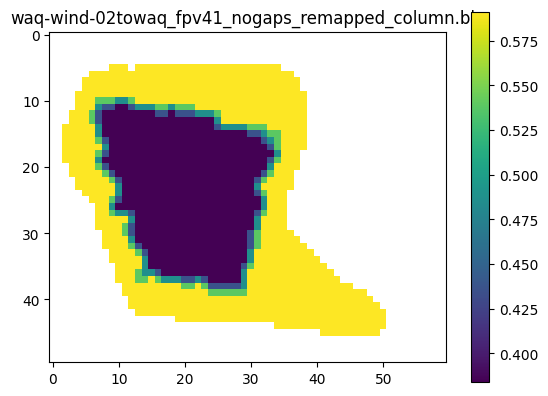

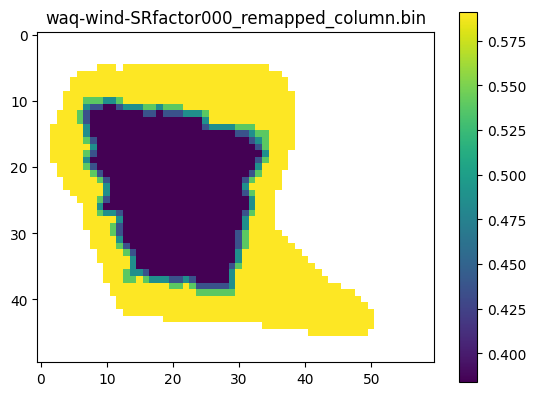

In [9]:
for p in paths_bin:
    bin_x = read_in_chunks(os.path.join(path_dir, p), num_chunks = 1)[0]
    grid_x = array_bin_to_grid(bin_x, new_to_old, segnum)
    plt.figure()
    plt.title(p)
    plt.imshow(np.rot90(grid_x[:, :, 8]), origin= 'upper')
    plt.colorbar()

In [43]:
pathtest = r"\\luna\fst\LEC\Users\midauarg\delft_modelling\wq_0.1min_secondfolder\waq-daily-sw_radiation_flux-02towaq_fpv41_nogaps_remapped_column.bin"

In [44]:
read_in_chunks(pathtest, 2)

{0: array([112.7051, 112.7051, 112.7051, ..., 112.7051, 112.7051, 112.7051],
       shape=(10999,), dtype=float32),
 86400: array([243.91698, 243.91698, 243.91698, ..., 243.91698, 243.91698,
        243.91698], shape=(10999,), dtype=float32)}